# Laborator

**Sarcină:** Dezbateți și adnotați rezolvările problemelor

## Regresie Liniara

### Cerință

Se dau temperaturile in Baia Mare la diferite ore timp de 12 ore... 
Task-ul principal este sa prezicem pe baza temperaturiilor cunoscute pentru ora urmatoare

Date:
- Temperatură (&deg;C): `[15, 18, 20, 22, 25, 27, 30, 32, 35, 37, 40, 38]`
- Ora: `[12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]`
- Temperatura este cuprinsa intre 10 si 40 (&deg;C) 
- Lista cu ore reprezinta orele din spate ex: 1 = 1 ora in urma, 2 = 2 ore in urma, etc...

Sarcini:
1. Vizualizarea datelor pentru a înțelege natura relației.
2. Antrenarea unui model de regresie liniară simplă.
3. Calcularea metricilor de evaluare: MAE, MSE, RMSE și R<sup>2</sup>.
4. Predicție pentru următoarea oră folosind modelul antrenat.
5. Discuție despre adecvarea modelului liniar (underfitting) și validitatea predicției.

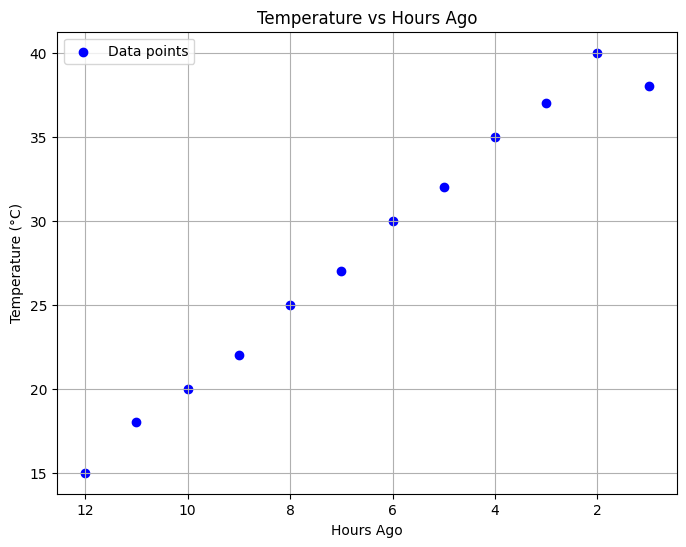

=== Linear Regression Metrics ===
MAE: 0.71
MSE: 1.08
RMSE: 1.04
R²: 0.9831
Coefficient: -2.30
Intercept: 43.23


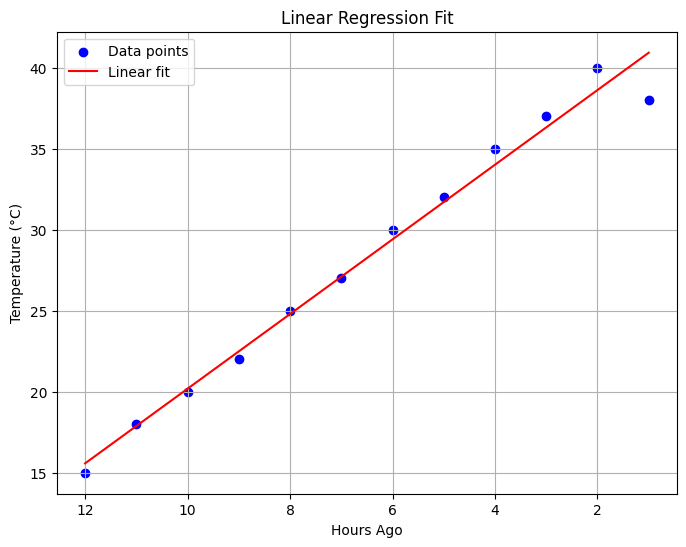


Prediction for next hour (0 hours ago): 43.23 °C


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

hours_ago = np.array([12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]).reshape(-1, 1)
temperatures = np.array([15, 18, 20, 22, 25, 27, 30, 32, 35, 37, 40, 38])

plt.figure(figsize=(8, 6))
plt.scatter(hours_ago, temperatures, color='blue', label='Data points')
plt.xlabel('Hours Ago')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Hours Ago')
plt.grid(True)
plt.legend()
plt.gca().invert_xaxis()
plt.show()

model = LinearRegression()
model.fit(hours_ago, temperatures)

predictions = model.predict(hours_ago)

mae = mean_absolute_error(temperatures, predictions)
mse = mean_squared_error(temperatures, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(temperatures, predictions)

print("=== Linear Regression Metrics ===")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")
print(f"Coefficient: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(hours_ago, temperatures, color='blue', label='Data points')
plt.plot(hours_ago, predictions, color='red', label='Linear fit')
plt.xlabel('Hours Ago')
plt.ylabel('Temperature (°C)')
plt.title('Linear Regression Fit')
plt.grid(True)
plt.legend()
plt.gca().invert_xaxis()
plt.show()

next_hour = np.array([[0]])
prediction_next = model.predict(next_hour)[0]
print(f"\nPrediction for next hour (0 hours ago): {prediction_next:.2f} °C")


## Regresie polinomială

### Cerință

Un magazin de înghețată vrea să prezică vânzările zilnice în funcție de temperatură.

Date:
- Temperatură (&deg;C): `[15, 18, 20, 22, 25, 27, 30, 32, 35, 37, 40]`
- Vânzări (unități): `[20, 35, 50, 70, 100, 130, 170, 190, 220, 235, 250]`

Sarcini:
1. Vizualizarea datelor (linear vs curved)
2. Antrenarea modelelor de regresie polinomială de grad 1, 2 și 3
3. Calculare MAE, MSE, RMSE și R<sup>2</sup>
4. Determinare ce temperatură e optimă
5. Predicție pentru 28&deg;C
6. Discuție overfitting vs underfitting

### Rezolvare

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

temperature = np.array([15, 18, 20, 22, 25, 27, 30, 32, 35, 37, 40]).reshape(-1, 1)
sales = np.array([20, 35, 50, 70, 100, 130, 170, 190, 220, 235, 250])

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.scatter(temperature, sales, color="blue", s=50)
plt.xlabel("Temperature (°C)")
plt.ylabel("Sales (units)")
plt.title("Original Data")
plt.grid(True)

degrees = [1, 2, 3]
models = {}
predictions = {}

for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(temperature)

    model = LinearRegression()
    model.fit(X_poly, sales)
    models[degree] = (poly, model)

    y_pred = model.predict(X_poly)
    predictions[degree] = y_pred

    mae = mean_absolute_error(sales, y_pred)
    mse = mean_squared_error(sales, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(sales, y_pred)

    print(f"\n=== Polynomial Degree {degree} ===")
    print(f"MAE:  {mae:.2f}")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

    print(f"Coefficients: {model.coef_}")
    print(f"Intercept: {model.intercept_:.2f}")

    temp_range = np.linspace(15, 40, 100).reshape(-1, 1)
    X_poly_range = poly.transform(temp_range)
    y_range = model.predict(X_poly_range)

    plt.subplot(1, 3, degree)
    plt.scatter(temperature, sales, color="blue", s=50, label="Data")
    plt.plot(temp_range, y_range, color="red", linewidth=2, label=f"Degree {degree}")
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Sales (units)")
    plt.title(f"Degree {degree} (R²={r2:.4f})")
    plt.legend()
    plt.grid(True)

print("\n=== Prediction for 28°C ===")
for degree in degrees:
    poly, model = models[degree]
    temp_28 = poly.transform([[28]])
    pred_28 = model.predict(temp_28)[0]
    print(f"Degree {degree}: {pred_28:.2f} units")

## Tabel Comparativ

| Aspect | Regresie Liniară | Regresie Polinomială |
| :--- | :--- | :--- |
| **Definiție** | Modelează relația dintre variabile ca o linie dreaptă: `y = mx + b`. | Modelează relația ca o curbă polinomială: `y = a_n x^n + ... + a_1 x + a_0`. |
| **Ipoteze** | Relație liniară între variabile, reziduuri independente. | Poate captura relații neliniare, ipotezele sunt similare, dar modelul este mai flexibil. |
| **Avantaje** | Simplu de implementat și interpretat, rapid de antrenat, bun pentru relații liniare. | Poate modela curbe complexe, mai precis pentru date neliniare, evită underfitting-ul. |
| **Dezavantaje** | Nu funcționează bine pentru date neliniare, risc de underfitting. | Risc de overfitting (supraajustare) cu grade înalte, mai complex și mai lent, necesită alegerea gradului optim. |
| **Când să folosești** | Când relația dintre variabile este liniară sau aproape liniară. | Când datele arată o relație curbă (ex: parabolică), pentru optimizări sau fenomene cu punct maxim/minim. |
| **Exemple de utilizare** | Predicția prețurilor imobiliare bazate pe suprafață, analiza vânzărilor în timp. | Predicția vânzărilor de înghețată în funcție de temperatură, randamentul culturilor în funcție de fertilizatori. |
| **Metrici de evaluare** | MAE, MSE, RMSE, R², evaluate pe date liniare. | Aceleași metrici, compară grade diferite pentru a evita overfitting-ul. |
| **Interpretabilitate** | Coeficienții sunt ușor de înțeles (panta și intercept). | Coeficienții devin mai complecși cu grade mai mari, greu de interpretat. |
| **Sensibilitate la date** | Robust la zgomot dacă relația este liniară, afectat de outlier-i. | Mai sensibil la outlier-i și zgomot, grade înalte pot amplifica erorile. |
| **Overfitting/Underfitting** | Underfitting pentru date neliniare. | Overfitting cu grade prea mari, underfitting cu grade prea mici. |

# Temă

**Sarcină:** Rezolvați și prezentați problemele următoare similar cu cele rezolvate la laborator.

Studenții de la specializarea Matematică informatică vor lucra în grupe de câte două persoane.

## Regresie polinomială

Un fermier dorește să prezică randamentul de grâu în funcție de cantitatea de fertilizator utilizată.

Date:
- Fertilizator (kg/ hectar): `[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]`
- Randament (tone/ hectar): `[2.1, 2.8, 3.6, 4.5, 5.2, 5.8, 6.2, 6.4, 6.5, 6.4, 6.2, 5.9, 5.4, 4.8, 4.0]`

Notă: prea puțin fertilizator = randament mic; cantitate optimă = randament mare; prea mult = scădere randament.

Sarcini:
1. Împărțire date în seturi de antrenament (primele 12 puncte) și testare (ultimele 3 puncte)
2. Antrenare modele de regresie polinomială (grad 1, 2, 3 și 4)
3. Calculare MAE, MSE, RMSE și R<sup>2</sup> atât pentru datele de antrenare cât și testare
4. Identificarea cantității optime de fertilizator
5. Explicare care grad reprezintă cel mai bine realitatea
6. Vizualizarea tuturor modelelor și discutarea overfitting

## Regresie Liniară
Un proprietar de cafenea vrea să prezică vânzările zilnice în funcție de numărul de clienți care intră pe zi.

Date:

Număr clienți: `[50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160]`

Vânzări (lei): `[200, 240, 280, 320, 360, 400, 440, 480, 520, 560, 600, 640]`

Sarcini:

1. Vizualizarea datelor pentru a înțelege natura relației.
2. Antrenarea unui model de regresie liniară simplă.
3. Calcularea metricilor de evaluare: MAE, MSE, RMSE și R².
4. Predicție pentru o zi cu 170 clienți folosind modelul antrenat.
5. Discuție despre adecvarea modelului liniar (underfitting) și validitatea predicției.